# Data snooping and multiple testing: do any of the configurations we tried actually work?

Three studies in this repository searched parameter grids:

- **time-series momentum:** 104 configurations (look-back x volatility window) on eight daily series;
- **currency style premia:** 54 monthly carry, momentum and value portfolios;
- **WTI-Brent pairs:** 70 configurations (Kalman state noise x entry x exit).

Each study reported the in-sample winner and diagnostics for that one choice (PBO, deflated Sharpe ratio). This note asks the question those diagnostics do not answer: **after accounting for every configuration tried, is there evidence that *any* of them has a positive expected return, and if so, which ones?**

**Answer in brief.** No. In every grid, and in every sample (full, in-sample, out-of-sample), the Reality Check and the SPA test fail to reject the hypothesis that no configuration beats doing nothing. The Romano-Wolf stepdown identifies no configuration at the 5% family-wise level.

What *looks* significant in isolation does not survive the correction:

- the best pairs configuration in sample has a naive p-value of 0.009 against an SPA p-value of 0.15;
- no momentum configuration beats the 12-month rule fixed in advance;
- the full-sample performance of all three baselines depends on a handful of days or months.

Methods: [learning note](../../docs/learning/statistics/data_snooping_and_multiple_testing.md). Engines: `backtest_engine.validation` (tests) and `backtest_engine._core` (joint stationary bootstrap in C++).

## 1. Research question

Given $K$ strategies evaluated on the same $T$ periods, with performance relative to a benchmark $d_{t,k} = r_{t,k} - b_t$:

1. Is $\max_k E[d_k] > 0$? This is the Reality Check (White, 2000) and the SPA test (Hansen, 2005).
2. For which $k$ is $E[d_k] > 0$, with the probability of any false discovery at most 5%? This is the Romano-Wolf stepdown (2005).
3. How many *independent* trials does each grid amount to, and what does that do to the deflated Sharpe ratio?
4. Is performance stable over time (Andrews sup-Wald break test), and how much of it comes from a few extreme periods?

## 2. Economic rationale

A researcher who tries $K$ variants and reports the best is reporting the maximum of $K$ noisy estimates. Under the null of no skill, that maximum is positive and grows like $\sqrt{2\ln K}$ standard errors.

The profession's reported alphas are therefore biased upwards (Harvey, Liu and Zhu, 2016). The only defence is to condition inference on the search. Trading capital allocated on a naive $t$-statistic funds the selection bias, not an edge.

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "backtest_engine").is_dir())
try:
    import backtest_engine
except ImportError:  # not installed: use the source folder (the extension must be built in place)
    sys.path.insert(0, str(ROOT / "scripts" / "backtest_engine"))
    import backtest_engine
from backtest_engine import data, fx_factors as fx, metrics as mt, strategies as st, synthetic, validation as va
from backtest_engine.figstyle import MUTED, NEGATIVE, SERIES, notebook_style

core = backtest_engine.require_cpp()

DATA_MODE = os.environ.get("BACKTEST_ENGINE_DATA_MODE", "official")   # "official" or "synthetic" (offline)
# Grids exactly as in the original studies (rules, costs, lags and in-sample periods fixed there, not here).
MOMENTUM = dict(lookbacks=list(range(10, 261, 10)), coms=[20.0, 40.0, 60.0, 90.0], asset_vol=0.40, max_leverage=5.0,
                cost=0.0005, lag=1, warmup=300, in_sample_end="2012-12-31")
CURRENCY = dict(cost_bp=3.0, in_sample_end="2012-12-31")
PAIRS = dict(deltas=[1e-6, 1e-5, 1e-4, 1e-3], entries=[1.0, 1.5, 2.0, 2.5, 3.0], exits=[0.0, 0.5, 1.0], cost=0.02,
             burn_in=60, in_sample_end="2009-12-31")
N_BOOT = 5000                  # bootstrap replicates for every test
SEED = 20260926                # replicate b uses the C++ random stream (SEED, b): results do not depend on threads
ALPHA = 0.05
OUTPUT_DIR = ROOT / "outputs" / "strategy_validation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
notebook_style()
print(f"backtest_engine {backtest_engine.__version__} | data mode: {DATA_MODE} | threads: {os.cpu_count()}")

backtest_engine 0.1.0 | data mode: official | threads: 4


## 3. Dataset

The grids are recomputed from the same sources and with the same rules as the original notebooks:

- **momentum:** ECB euro reference rates, EIA spot prices and the Federal Reserve 10-year yield (FRED), 1999-2025, daily;
- **currency:** ECB month-end spot rates and OECD 3-month rates (FRED), monthly;
- **pairs:** EIA WTI and Brent spot prices, 1988-2025, daily P&L in USD per barrel.

The currency grid is used on the common sample in which all 54 configurations trade (the value signals need five years of history, so it starts in August 2004).

**Caveat carried over from the studies.** Momentum and pairs trade **spot prices, not tradable futures**, so their returns omit the roll yield (see the [futures learning note](../../docs/learning/futures/futures_rolls_and_carry.md)). The tests below are valid for the return series as defined; what those series mean economically is limited by that choice.

In [2]:
t0 = time.perf_counter()
if DATA_MODE == "official":
    universe = data.load_momentum_universe("1999-01-04", "2025-12-31")
    pair = data.load_wti_brent("1988-01-01", "2025-12-31")
    fx_panel = fx.load_fx_panel(official=True)
else:
    universe = synthetic.trending_prices(n=7000, n_assets=8, start="1999-01-04")
    pair = synthetic.cointegrated_pair(n=9500, start="1988-01-04").rename(columns={"y": "WTI", "x": "Brent"})
    fx_panel = fx.load_fx_panel(official=False)


def momentum_grid(cost=MOMENTUM["cost"]):
    g, configs = st.tsmom_grid(universe, MOMENTUM["lookbacks"], MOMENTUM["coms"], MOMENTUM["asset_vol"],
                               MOMENTUM["max_leverage"], cost, MOMENTUM["lag"])
    return g.iloc[MOMENTUM["warmup"]:]


grids = {"momentum": momentum_grid()}
rx = fx.excess_returns(fx_panel["spot"], fx_panel["rates"])
grids["currency"] = fx.strategy_grid(fx_panel["spot"], fx_panel["rates"], rx, CURRENCY["cost_bp"]).dropna()
y, x = pair["WTI"], pair["Brent"]
mle = st.fit_kalman_mle(y.loc[:PAIRS["in_sample_end"]], x.loc[:PAIRS["in_sample_end"]], burn_in=PAIRS["burn_in"])
pairs_pnl, _ = st.pairs_grid(y, x, PAIRS["deltas"] + [mle["delta"]], mle["obs_var"], PAIRS["entries"], PAIRS["exits"],
                             cost_per_unit=PAIRS["cost"], start=PAIRS["burn_in"])
grids["pairs"] = pairs_pnl.iloc[PAIRS["burn_in"]:]

# Baselines fixed a priori in the original studies.
baselines = {
    "momentum": st.tsmom_backtest(universe, 252, 60.0, MOMENTUM["asset_vol"], MOMENTUM["max_leverage"], MOMENTUM["cost"],
                                  MOMENTUM["lag"])["returns"].iloc[MOMENTUM["warmup"]:],
    "currency": grids["currency"]["carry n=3 equal"],
    "pairs": grids["pairs"][[c for c in grids["pairs"] if c.startswith(f"d={mle['delta']:.3g} in=2 out=0.5")][0]],
}
SPLITS = {"momentum": MOMENTUM["in_sample_end"], "currency": CURRENCY["in_sample_end"], "pairs": PAIRS["in_sample_end"]}
PERIODS_PER_YEAR = {"momentum": 252, "currency": 12, "pairs": 252}
print(f"data and grids in {time.perf_counter() - t0:.1f} s")
display(pd.DataFrame({name: {"configurations": g.shape[1], "periods": g.shape[0], "first": f"{g.index[0]:%Y-%m-%d}",
                             "last": f"{g.index[-1]:%Y-%m-%d}", "in-sample end": SPLITS[name]}
                      for name, g in grids.items()}).T)

data and grids in 1.5 s


,configurations,periods,first,last,in-sample end
momentum,104,6692,2000-02-28,2025-12-31,2012-12-31
currency,54,257,2004-08-31,2025-12-31,2012-12-31
pairs,70,8015,1988-04-05,2025-12-31,2009-12-31


## 4. Timing and information assumptions

**Construction of the grid returns:**

- **momentum:** signals at the close, one-day execution lag, 5 bp per unit of turnover;
- **currency:** weights at month-end earn the next month's excess return, 3 bp per unit of turnover;
- **pairs:** one-day lag, 0.02 USD per unit traded.

These are the studies' rules. The in-sample periods (to 2012 for momentum and currency, to 2009 for pairs) were fixed there and are not revisited here.

**Assumptions of the tests:**

- the $d_{t,k}$ are strictly stationary and weakly dependent (the stationary bootstrap resamples blocks to keep that dependence);
- the grid is the complete set of configurations tried on these data. The committee study counts **184 research trials** in total; the grids cover most but not all of them, so the results below are, if anything, too generous.

## 5. Methodology

With $\bar d_k$ the mean, $\hat\omega_k^2$ the stationary-bootstrap variance of $\sqrt T \bar d_k$ and $t_k = \sqrt T \bar d_k / \hat\omega_k$:

| Procedure | Statistic | Null distribution (bootstrap, $B$ = 5,000) |
| --- | --- | --- |
| Naive | $\max_k t_k$ compared with $N(0,1)$ | ignores the search |
| Reality Check | $V = \max_k \sqrt T \bar d_k$ | $\max_k \sqrt T(\bar d^*_k - \bar d_k)$ (all at the boundary) |
| SPA (consistent) | $T_{SPA} = \max(0, \max_k t_k)$ | recentred: strategies significantly worse than the benchmark keep their negative mean |
| Romano-Wolf | stepdown on sorted $t_k$ | $\max_{l \ge i} t^*_l$ over the not-yet-rejected set |
| Effective trials | $N_{eff}$ with $E[\max \text{ of } N_{eff} \text{ i.i.d. } N(0,1)] = E[\max_k t^*_k]$ | same bootstrap draws |
| Break test | $\sup_m$ Wald for a change in mean (15% trimming) | simulated Brownian bridge (Andrews, 1993) |

The mean block length is the median Politis-White length across configurations.

## 6. Exploratory evidence: how many different bets are in a grid?

Configurations of the same grid are highly correlated: neighbouring look-backs trade almost the same positions. The table reports four summaries of that dependence:

- the average pairwise correlation of the configurations;
- the share of variance explained by the first principal component;
- the effective number of trials, estimated from the bootstrap draws that the tests use;
- the effective number from a Gaussian approximation.

A grid of 104 momentum configurations contains the selection opportunity of only about six independent strategies.

In [3]:
tests = {name: va.SnoopingTest(g, n_boot=N_BOOT, seed=SEED) for name, g in grids.items()}
rows = {}
for name, g in grids.items():
    live = g.loc[:, g.std() > 0]            # a configuration that never trades has no correlation (as in SnoopingTest)
    corr = np.corrcoef(live.to_numpy(), rowvar=False)
    upper = corr[np.triu_indices_from(corr, 1)]
    eig = np.linalg.eigvalsh(corr)
    rows[name] = {"configurations": g.shape[1], "never traded": g.shape[1] - live.shape[1],
                  "mean correlation": upper.mean(), "first PC share": eig[-1] / eig.sum(),
                  "effective trials (bootstrap)": tests[name].effective_trials(),
                  "effective trials (Gaussian)": va.effective_number_of_trials(g, seed=SEED),
                  "mean block (days or months)": tests[name].mean_block}
dependence = pd.DataFrame(rows).T
display(dependence)

,configurations,never traded,mean correlation,first PC share,effective trials (bootstrap),effective trials (Gaussian),mean block (days or months)
momentum,104.000,0.000,0.613,0.629,5.460,5.722,3.858
currency,54.000,0.000,0.206,0.491,9.337,9.434,1.194
pairs,70.000,0.000,0.649,0.700,5.128,6.099,4.140


## 7. The tests on the full sample

For each grid, the chart gives the probability that chance alone produces a best $t$-statistic at least as large as the value on the horizontal axis:

- **dashed:** for a single configuration tested alone (the naive view);
- **solid:** for the best of the whole grid, from the SPA bootstrap null.

At the observed maximum, the vertical gap between the two curves is the correction for the search: the naive $p$-value becomes the SPA $p$-value.

,mean block,best,best t,naive p,Reality Check p,SPA p (consistent),SPA p (lower),SPA p (upper),Romano-Wolf rejections (5%),Bonferroni rejections (5%)
momentum,3.858,L=240 com=90,1.369,0.085,0.433,0.380,0.319,0.435,0,0
currency,1.194,carry n=2 equal,1.284,0.100,0.536,0.629,0.462,0.629,0,0
pairs,4.140,d=0.0001 in=2.5 out=0.5,1.941,0.026,0.197,0.195,0.170,0.195,0,0


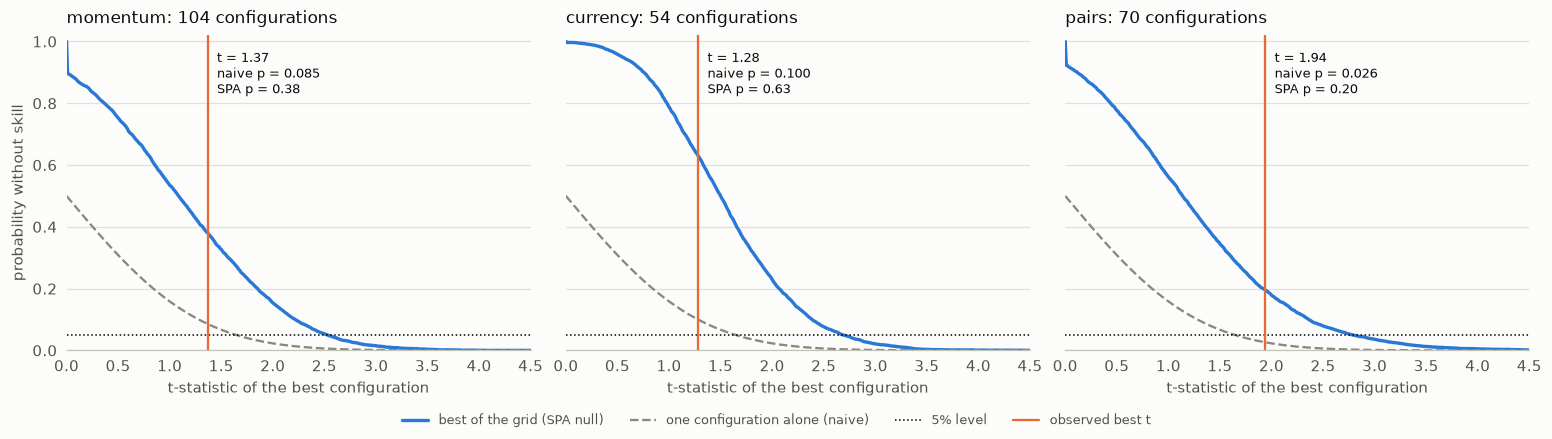

In [4]:
def results_table(tests):
    return pd.DataFrame({name: t.summary(ALPHA) for name, t in tests.items()}).T.drop(columns=["strategies", "periods"])


full = results_table(tests)
display(full)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9), sharey=True)
x_grid = np.linspace(0.0, 4.5, 451)
for ax, (name, test) in zip(axes, tests.items()):
    null = np.sort(test.null_max_t("consistent"))
    survival = 1.0 - np.searchsorted(null, x_grid, side="left") / null.size
    ax.plot(x_grid, survival, color=SERIES[0], lw=2.2, label="best of the grid (SPA null)")
    ax.plot(x_grid, stats.norm.sf(x_grid), color=MUTED, ls="--", lw=1.5, label="one configuration alone (naive)")
    ax.axhline(ALPHA, color="k", ls=":", lw=1.0, label="5% level")
    observed = test.spa()["statistic"]
    ax.axvline(observed, color=SERIES[1], lw=1.5, label="observed best t")
    ax.annotate(f"t = {observed:.2f}\nnaive p = {stats.norm.sf(observed):.3f}\nSPA p = {test.spa()['p_consistent']:.2f}",
                (observed, 0.97), xytext=(6, 0), textcoords="offset points", va="top", fontsize=8.5)
    ax.set(title=f"{name}: {test.n_strategies} configurations", xlabel="t-statistic of the best configuration",
           ylim=(0, 1.02), xlim=(0, 4.5))
axes[0].set_ylabel("probability without skill")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center", ncol=4)
fig.savefig(OUTPUT_DIR / "max_t_null.png", dpi=150)

**Reading.** The best momentum, currency and pairs configurations have $t$-statistics between about 1.3 and 1.9. Each would pass or nearly pass a naive one-sided test. Each sits inside the bulk of what the search alone produces: the SPA $p$-values are 0.20-0.63, and the Reality Check agrees.

Romano-Wolf and Bonferroni reject nothing. The chart below shows why: the sorted $t$-statistics of every configuration stay below the stepdown threshold.

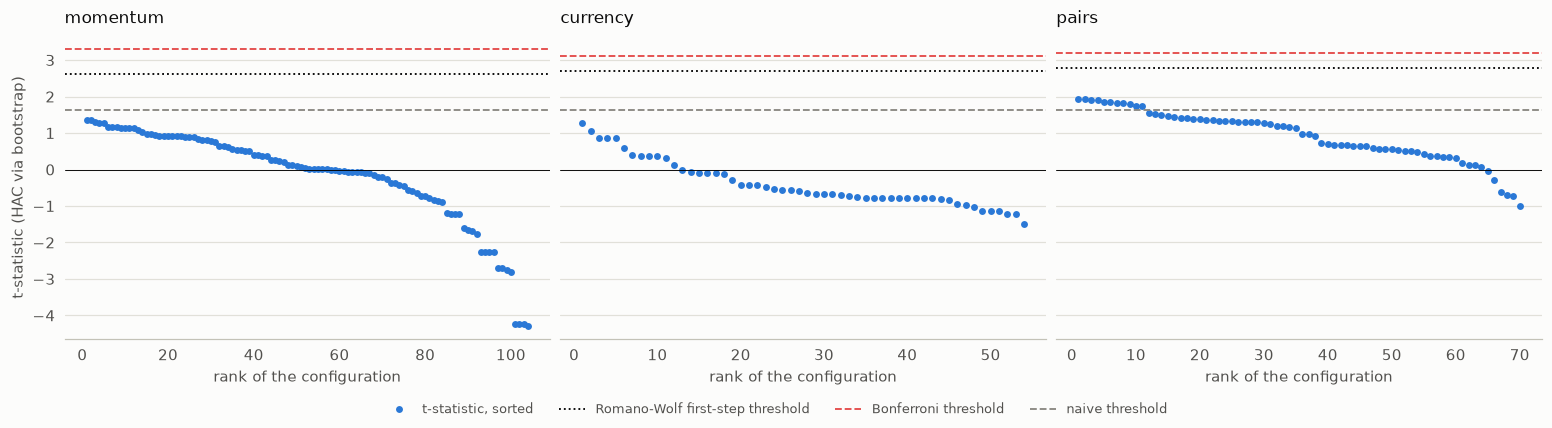

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, (name, test) in zip(axes, tests.items()):
    table = test.romano_wolf(ALPHA)
    rank = np.arange(1, len(table) + 1)
    ax.plot(rank, table["t"], "o", ms=3.5, color=SERIES[0], label="t-statistic, sorted")
    ax.axhline(np.quantile(test.null_max_t("upper"), 1 - ALPHA), color="k", ls=":", lw=1.2,
               label="Romano-Wolf first-step threshold")
    ax.axhline(stats.norm.isf(ALPHA / test.n_strategies), color=NEGATIVE, ls="--", lw=1.2, label="Bonferroni threshold")
    ax.axhline(1.645, color=MUTED, ls="--", lw=1.2, label="naive threshold")
    ax.axhline(0, color="k", lw=0.6)
    ax.set(title=name, xlabel="rank of the configuration")
axes[0].set_ylabel("t-statistic (HAC via bootstrap)")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center", ncol=4)
fig.savefig(OUTPUT_DIR / "sorted_t.png", dpi=150)

## 8. Validation: do the procedures behave as claimed on data like these?

The procedures are checked in the test suite (`tests/backtest_engine/test_validation.py`) for:

- size, power and family-wise error on simulated grids;
- agreement of the variance formula with simulation;
- published critical values for the break test.

Here the check is repeated with the actual dependence of the momentum grid. There are 60 simulated grids of 104 configurations without any skill, drawn from the grid's sample correlation matrix with $T$ = 1,000 periods and 299 bootstrap replicates each. The rejection rates at 5% show what each method would conclude on data with this structure and no skill at all.

In [6]:
corr = np.corrcoef(grids["momentum"].to_numpy(), rowvar=False)
eig, vec = np.linalg.eigh(corr)
factor = vec * np.sqrt(np.clip(eig, 0.0, None))
outcomes = []
for s in range(60):
    Z = np.random.default_rng(SEED + s).standard_normal((1000, corr.shape[0])) @ factor.T
    sim = va.SnoopingTest(Z, mean_block=1.0, n_boot=299, seed=s)
    outcomes.append({"naive": sim.naive()["p"] < ALPHA, "Reality Check": sim.reality_check()["p"] < ALPHA,
                     "SPA (consistent)": sim.spa()["p_consistent"] < ALPHA,
                     "Romano-Wolf (any rejection)": bool(sim.romano_wolf(ALPHA)["reject"].any())})
size = pd.DataFrame(outcomes).mean().rename("rejection rate without skill (nominal 5%)")
display(size.to_frame())
print(f"binomial standard error of a 5% rate with 60 simulations: {np.sqrt(0.05 * 0.95 / 60):.3f}")

,rejection rate without skill (nominal 5%)
naive,0.383
Reality Check,0.050
SPA (consistent),0.033
Romano-Wolf (any rejection),0.033


binomial standard error of a 5% rate with 60 simulations: 0.028


## 9. In-sample and out-of-sample

Selection happened on the in-sample periods, so the tests are repeated separately on each side of the split. The same bootstrap also gives the effective number of trials used below.

In [7]:
split_rows = {}
for name, g in grids.items():
    cut = pd.Timestamp(SPLITS[name])
    for label, sub in (("in sample", g.loc[:cut]), ("out of sample", g.loc[cut + pd.Timedelta(days=1):])):
        split_rows[(name, label)] = va.SnoopingTest(sub, n_boot=N_BOOT, seed=SEED).summary(ALPHA)
by_sample = pd.DataFrame(split_rows).T
display(by_sample[["periods", "best", "best t", "naive p", "Reality Check p", "SPA p (consistent)",
                   f"Romano-Wolf rejections ({ALPHA:.0%})"]])

periods                   best best t naive p  \
momentum in sample        3327           L=230 com=90  1.225   0.110   
         out of sample    3365           L=210 com=20  1.143   0.127   
currency in sample         101        carry n=2 equal  1.081   0.140   
         out of sample     156        carry n=2 equal  0.730   0.233   
pairs    in sample        4095  d=0.0001 in=3 out=0.5  2.362   0.009   
         out of sample    3920   d=0.001 in=2 out=0.5  1.372   0.085   

                       Reality Check p SPA p (consistent)  \
momentum in sample               0.513              0.490   
         out of sample           0.532              0.485   
currency in sample               0.642              0.751   
         out of sample           0.889              0.874   
pairs    in sample               0.148              0.149   
         out of sample           0.282              0.397   

                       Romano-Wolf rejections (5%)  
momentum in sample                               0  
         out of sample                           0  
currency in sample                               0  
         out of sample                           0  
pairs    in sample                               0  
         out of sample                           0

**Deflated Sharpe ratio with the effective number of trials.** The DSR asks whether the best Sharpe ratio exceeds the expected maximum of $N$ trials under the null. Counting all $K$ configurations as independent overstates $N$; the effective number from section 6 corrects that. The DSR is shown both ways, next to the SPA $p$-value.

The two measures answer different questions under different assumptions:

- **DSR** uses the selected strategy's own moments and assumes i.i.d. returns.
- **SPA** bootstraps the whole grid with its serial dependence.

In [8]:
dsr_rows = {}
for name, g in grids.items():
    best = tests[name].naive()["best"]
    trial_sharpes = g.mean() / g.std()
    raw = mt.deflated_sharpe_ratio(g[best], trial_sharpes)
    eff = mt.deflated_sharpe_ratio(g[best], trial_sharpes, n_trials=dependence.loc[name, "effective trials (bootstrap)"])
    dsr_rows[name] = {"best": best, "annualised Sharpe": mt.sharpe_ratio(g[best], PERIODS_PER_YEAR[name]),
                      "DSR (all trials)": raw["dsr"], "trials": raw["n_trials"], "DSR (effective trials)": eff["dsr"],
                      "effective trials": eff["n_trials"], "SPA p (consistent)": full.loc[name, "SPA p (consistent)"]}
display(pd.DataFrame(dsr_rows).T)

,best,annualised Sharpe,DSR (all trials),trials,DSR (effective trials),effective trials,SPA p (consistent)
momentum,L=240 com=90,0.271,0.019,104,0.383,5.460,0.380
currency,carry n=2 equal,0.278,0.420,54,0.610,9.337,0.629
pairs,d=0.0001 in=2.5 out=0.5,0.328,0.651,70,0.962,5.128,0.195


## 10. Costs

Costs decide the momentum result. Without costs, the best momentum configuration has a $t$-statistic of about 2.2 and an SPA $p$-value of about 0.13, still not significant. At the study's 5 bp per unit of turnover it falls to about 1.4 (SPA 0.38), and at 10 bp to about 0.6.

In [9]:
cost_rows = {f"{bp:g} bp": va.SnoopingTest(momentum_grid(bp / 1e4), n_boot=N_BOOT, seed=SEED).summary(ALPHA)
             for bp in (0, 5, 10)}
display(pd.DataFrame(cost_rows).T[["best", "best t", "naive p", "Reality Check p", "SPA p (consistent)"]])

,best,best t,naive p,Reality Check p,SPA p (consistent)
0 bp,L=240 com=60,2.161,0.015,0.128,0.133
5 bp,L=240 com=90,1.369,0.085,0.433,0.380
10 bp,L=240 com=90,0.596,0.276,0.786,0.684


## 11. Risk analysis: stability over time and dependence on single episodes

For the three baselines fixed in advance (12-month momentum; carry, long 3 and short 3 currencies; pairs with the textbook 2.0/0.5 thresholds), two diagnostics:

- the Andrews sup-Wald test of a single break in the mean;
- the annualised Sharpe ratio after removing the $n$ best periods (days, or months for carry).

A result that disappears when a few periods are removed describes those periods, not a repeatable edge.

,statistic,p,break,mean before,mean after
momentum,2.905,0.588,2016-01-20 00:00:00,0.000,-0.000
currency,1.977,0.797,2007-10-31 00:00:00,0.006,0.001
pairs,3.041,0.560,2020-03-18 00:00:00,0.004,0.032


which                     best removed  none  worst removed
baseline periods removed                                   
momentum 0                         NaN 0.274            NaN
         1                       0.244   NaN          0.290
         2                       0.219   NaN          0.303
         5                       0.169   NaN          0.337
         10                      0.106   NaN          0.390
         20                      0.008   NaN          0.478
currency 0                         NaN 0.232            NaN
         1                       0.187   NaN          0.317
         2                       0.149   NaN          0.371
         3                       0.113   NaN          0.415
         5                       0.061   NaN          0.504
         10                     -0.058   NaN          0.688
pairs    0                         NaN 0.231            NaN
         1                       0.163   NaN          0.245
         2                       0.111   NaN          0.259
         5                      -0.027   NaN          0.298
         10                     -0.238   NaN          0.348
         20                     -0.556   NaN          0.414

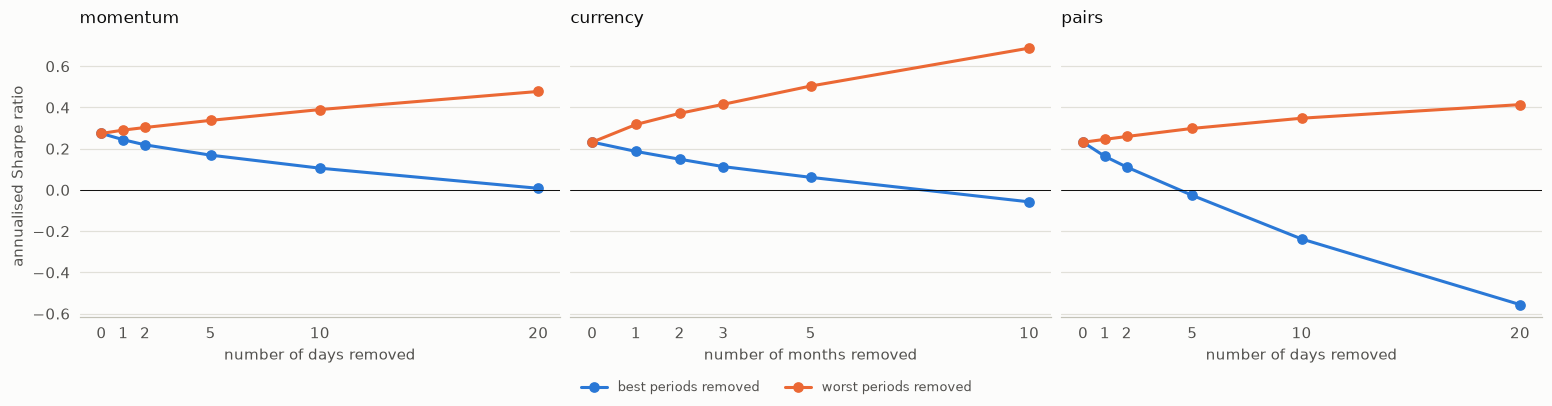

In [10]:
breaks = pd.DataFrame({name: va.sup_wald_break(r) for name, r in baselines.items()}).T
display(breaks)
removals = {"momentum": (0, 1, 2, 5, 10, 20), "currency": (0, 1, 2, 3, 5, 10), "pairs": (0, 1, 2, 5, 10, 20)}
episodes = {name: va.episode_dependence(r, removals[name], PERIODS_PER_YEAR[name]) for name, r in baselines.items()}

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for ax, (name, table) in zip(axes, episodes.items()):
    n = [k for k, _ in table.index]
    best = table.xs("best removed", level="which")["Sharpe"] if len(n) > 1 else None
    worst = table.xs("worst removed", level="which")["Sharpe"]
    base = table.loc[(0, "none"), "Sharpe"]
    xs = [0] + list(best.index)
    ax.plot(xs, [base] + list(best), "o-", color=SERIES[0], label="best periods removed")
    ax.plot(xs, [base] + list(worst), "o-", color=SERIES[1], label="worst periods removed")
    ax.axhline(0, color="k", lw=0.6)
    unit = "months" if name == "currency" else "days"
    ax.set_xticks(xs)
    ax.set(title=name, xlabel=f"number of {unit} removed")
axes[0].set_ylabel("annualised Sharpe ratio")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center", ncol=2)
fig.savefig(OUTPUT_DIR / "episode_dependence.png", dpi=150)
display(pd.concat(episodes, names=["baseline"]).unstack("which")["Sharpe"])

**Reading.** None of the break tests rejects a constant mean at conventional levels ($p$ = 0.56-0.80). With this much noise, a change in performance of the size seen (for example, momentum before and after 2016) is not distinguishable from chance.

The episode analysis is more telling:

- removing the **5 best days** takes the pairs baseline from a Sharpe ratio of about 0.23 to about zero;
- removing 20 days does the same to momentum;
- removing 5 months takes carry from 0.23 to 0.06.

The three baselines earn their full-sample Sharpe ratios in a handful of periods. For pairs, these are the April 2020 oil-price collapse, whose spot prints are not tradable (section 3).

## 12. Robustness

- **Block length:** halving or doubling the mean block length moves the SPA $p$-values by at most about 0.03 (momentum stays at 0.38).
- **Benchmark:** tested against the a-priori 12-month rule instead of zero, the best of the 104 momentum configurations has a $t$-statistic of about zero (SPA $p$ = 1.0). The grid search added nothing to the rule chosen before looking at the data.

In [11]:
robust = {}
for name, g in grids.items():
    for mult in (0.5, 1.0, 2.0):
        test = va.SnoopingTest(g, mean_block=max(1.0, tests[name].mean_block * mult), n_boot=N_BOOT, seed=SEED)
        robust[(name, f"block x {mult:g}")] = {"mean block": test.mean_block, "SPA p (consistent)": test.spa()["p_consistent"],
                                             "Reality Check p": test.reality_check()["p"]}
display(pd.DataFrame(robust).T)
vs_rule = va.SnoopingTest(grids["momentum"], benchmark=baselines["momentum"].reindex(grids["momentum"].index),
                          n_boot=N_BOOT, seed=SEED)
print("Momentum grid against the 12-month rule:", {k: round(v, 3) if isinstance(v, float) else v
                                                  for k, v in vs_rule.summary(ALPHA).items()})

mean block  SPA p (consistent)  Reality Check p
momentum block x 0.5       1.929               0.378            0.437
         block x 1         3.858               0.380            0.433
         block x 2         7.716               0.376            0.429
currency block x 0.5       1.000               0.631            0.545
         block x 1         1.194               0.629            0.536
         block x 2         2.388               0.652            0.527
pairs    block x 0.5       2.070               0.208            0.210
         block x 1         4.140               0.195            0.197
         block x 2         8.280               0.172            0.188

Momentum grid against the 12-month rule: {'strategies': 104, 'periods': 6692, 'mean block': 3.823, 'best': 'L=240 com=60', 'best t': -0.029, 'naive p': 0.511, 'Reality Check p': 0.99, 'SPA p (consistent)': 1.0, 'SPA p (lower)': 1.0, 'SPA p (upper)': 1.0, 'Romano-Wolf rejections (5%)': 0, 'Bonferroni rejections (5%)': 0}


## 13. Failure modes of this analysis

- **Incomplete trial count.** The grids are a subset of the research trials (184 counted in the committee study). Tests on the grid alone are optimistic, which strengthens rather than weakens the negative conclusion.
- **Non-stationarity.** RC, SPA and Romano-Wolf assume stationary, weakly dependent $d_t$. Regime shifts (the break tests have low power) could hide a strategy that works in some regimes and loses in others; the tests would average them.
- **Low power.** Section 8 shows the tests keep their size. Power is limited by the sample: a configuration with a true annual Sharpe ratio of 0.3 needs decades of data to be detected even without any search. "Not significant" is not "no edge"; it is "no evidence of an edge".
- **One-sided nulls with an arbitrary benchmark.** Zero is the natural benchmark for self-financing strategies. For spot-based momentum, "zero" ignores funding and carry (section 3).
- **Correlated tests across grids.** Each grid is tested separately. A portfolio-level claim would need a joint test over the union of all configurations.

## 14. Conclusion

After conditioning on the search, **none of the 228 configurations shows evidence of a positive expected return**, in sample or out of sample. The in-sample winners that looked significant in isolation are what selection from correlated grids produces by chance.

The conclusions of the original studies (no-go for momentum, carry and pairs as standalone strategies) are confirmed with methods that account for every configuration tried. The effective number of trials (about 5-9 per grid) is the right input to the deflated Sharpe ratio. Where the two disagree (pairs: DSR 0.96 with effective trials, SPA $p$ = 0.20), the disagreement comes from the DSR's i.i.d. assumption and single-strategy view.

## 15. Limitations

- Spot proxies for commodities (momentum, pairs): to be redone on tradable futures returns with `backtest_engine.futures` once contract data are available.
- Small grids by industry standards, and short currency samples (257 months in total, 101 in sample).
- The effective number of trials is an estimate. Two methods agree here (bootstrap and Gaussian); a clustering approach (Lopez de Prado, 2018) would be a third.
- Stationary bootstrap only; block-length choice is automatic and shown not to matter here.

### References

- Andrews, D. W. K. (1993). Tests for parameter instability and structural change with unknown change point. *Econometrica*, 61(4), 821-856.
- Hansen, P. R. (2005). A test for superior predictive ability. *Journal of Business and Economic Statistics*, 23(4), 365-380.
- Harvey, C. R., Liu, Y. and Zhu, H. (2016). ... and the cross-section of expected returns. *Review of Financial Studies*, 29(1), 5-68.
- Lopez de Prado, M. (2018). *Advances in Financial Machine Learning*. Wiley.
- Patton, A., Politis, D. N. and White, H. (2009). Correction to "Automatic block-length selection for the dependent bootstrap". *Econometric Reviews*, 28(4), 372-375.
- Politis, D. N. and Romano, J. P. (1994). The stationary bootstrap. *Journal of the American Statistical Association*, 89(428), 1303-1313.
- Politis, D. N. and White, H. (2004). Automatic block-length selection for the dependent bootstrap. *Econometric Reviews*, 23(1), 53-70.
- Romano, J. P. and Wolf, M. (2005). Stepwise multiple testing as formalized data snooping. *Econometrica*, 73(4), 1237-1282.
- Romano, J. P. and Wolf, M. (2016). Efficient computation of adjusted p-values for resampling-based stepdown multiple testing. *Statistics and Probability Letters*, 113, 38-40.
- White, H. (2000). A reality check for data snooping. *Econometrica*, 68(5), 1097-1126.